In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

# Load datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum_data = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip_data = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category_data = pd.read_csv("../data/raw/05_category_inflows.csv")
folio_data = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance_data = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [2]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum_data,
    "SIP": sip_data,
    "Category": category_data,
    "Folio": folio_data,
    "Performance": performance_data,
    "Transactions": transactions,
    "Holdings": holdings
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)


Fund Master
(40, 15)

NAV History
(46000, 3)

AUM
(90, 5)

SIP
(48, 6)

Category
(144, 3)

Folio
(21, 6)

Performance
(40, 19)

Transactions
(32778, 13)

Holdings
(322, 8)


## NAV Trend Analysis

This chart shows the daily NAV movement of all mutual fund schemes from 2022–2026.
Most schemes demonstrate long-term growth with temporary market corrections.

In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

## AUM Growth Analysis

Fund houses show steady AUM expansion across years, reflecting growing investor participation in mutual funds.

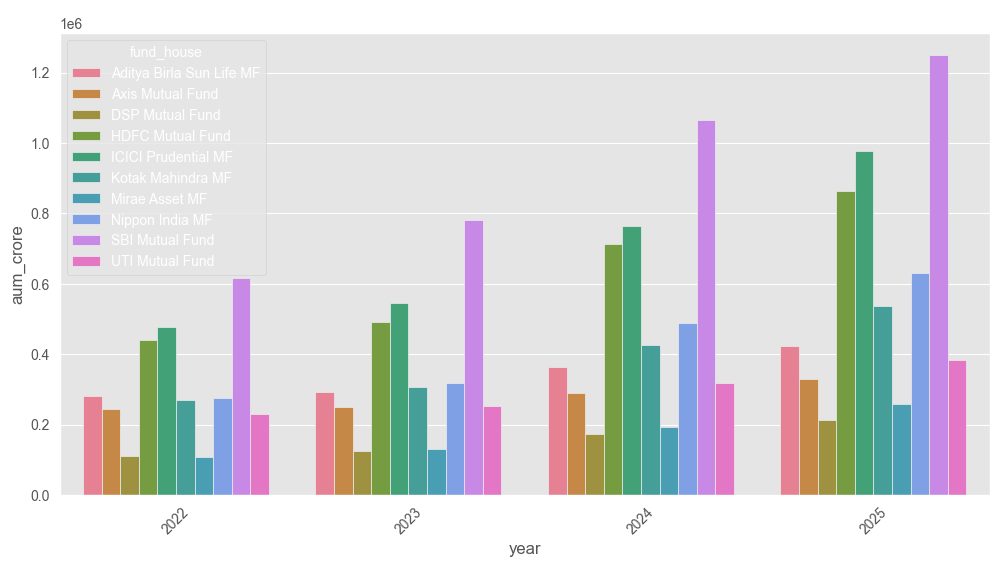

In [4]:
aum_data["date"] = pd.to_datetime(aum_data["date"])

aum_data["year"] = aum_data["date"].dt.year

yearly_aum = (
    aum_data
    .groupby(["year", "fund_house"])["aum_crore"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

## SIP Inflow Trend

Monthly SIP inflows from 2022–2025 showing growth in retail participation.

In [6]:
sip_data["month"] = pd.to_datetime(sip_data["month"])

fig = px.line(
    sip_data,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

## Category Wise Net Inflows

Heatmap showing category-wise monthly fund inflows.

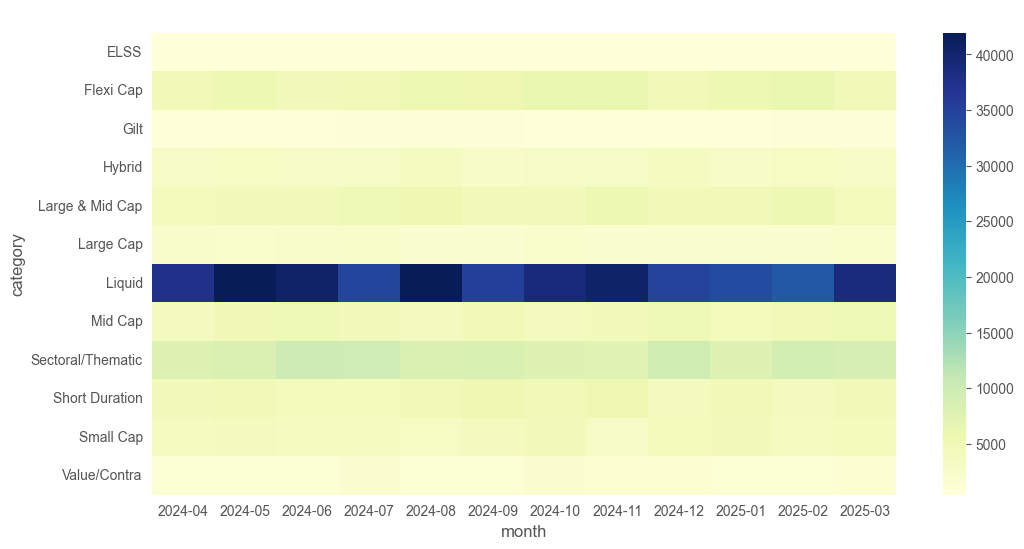

In [7]:
heatmap_data = category_data.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

## Investor Demographics

Distribution of investors across age groups.

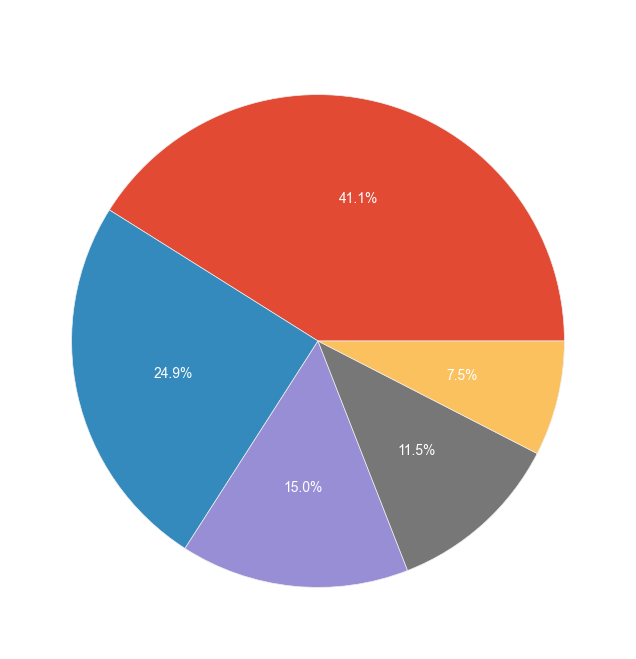

In [8]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.show()

## Gender Distribution

This chart shows the proportion of male and female investors participating in mutual fund investments.

### Insight
The investor base is distributed across genders, highlighting participation trends in the mutual fund ecosystem.

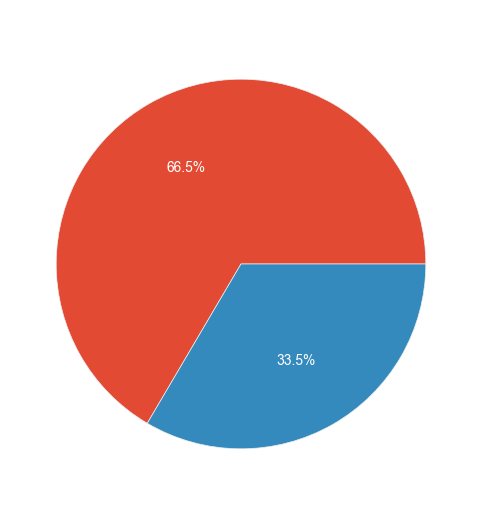

In [9]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

## State-wise SIP Contribution

This chart compares total SIP investment amounts across different states.

### Insight
A few states contribute a significant share of overall SIP investments, indicating regional concentration of mutual fund participation.

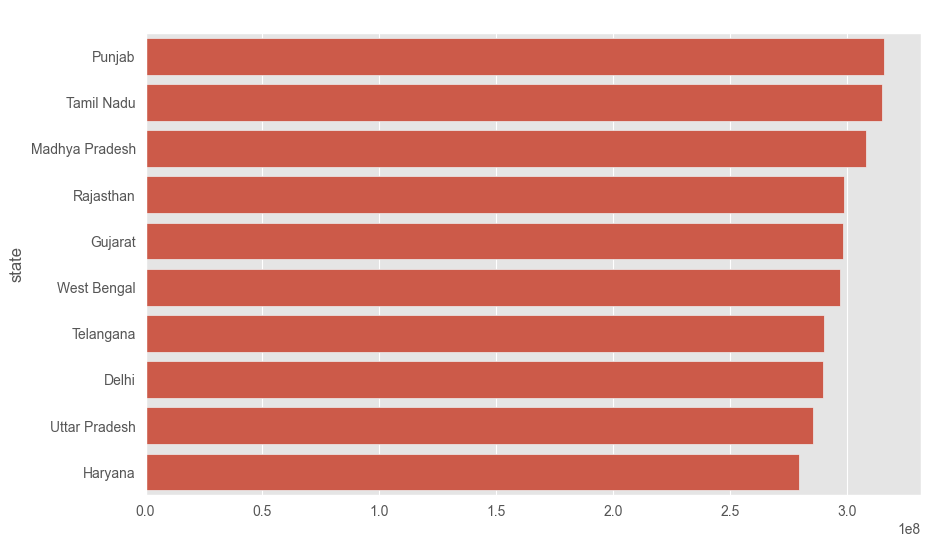

In [10]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Top States by SIP Amount")

plt.show()

## Folio Count Growth Analysis

This chart tracks the growth in mutual fund folios over time.

### Insight
The steady increase in folio counts reflects rising investor awareness and growing adoption of mutual funds across India.

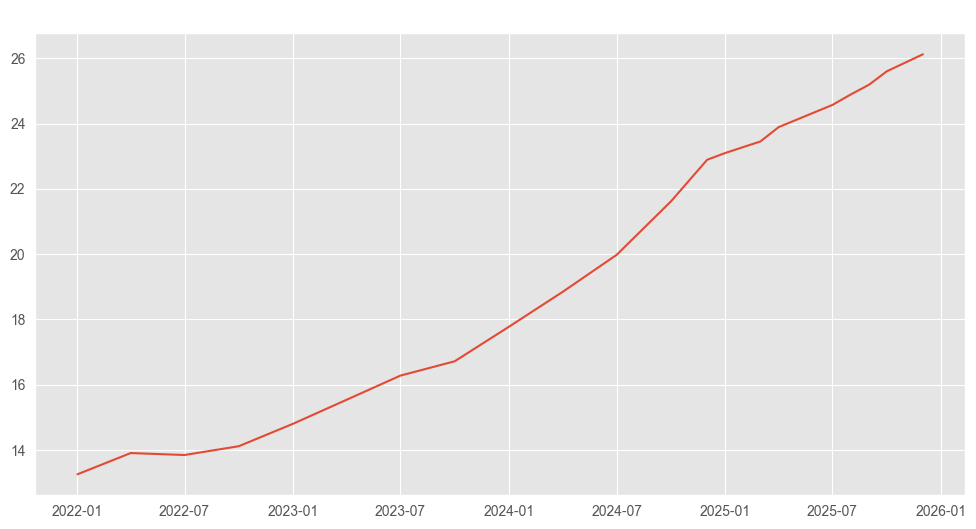

In [11]:
folio_data["month"] = pd.to_datetime(folio_data["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio_data["month"],
    folio_data["total_folios_crore"]
)

plt.title("Folio Count Growth")

plt.show()

## SIP Amount Distribution by Age Group

This box plot shows the distribution of SIP investment amounts across different age groups.

### Insight
Investment behavior varies significantly across age groups, with some groups showing higher median investment amounts.

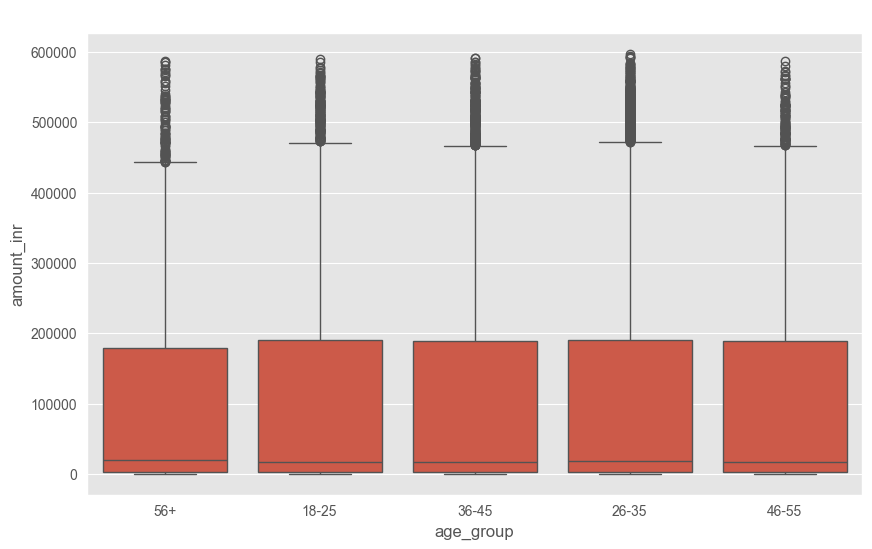

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.show()

## T30 vs B30 Investor Distribution

This chart compares investor participation between T30 and B30 cities.

### Insight
The comparison highlights the concentration of mutual fund investments across major and emerging cities.

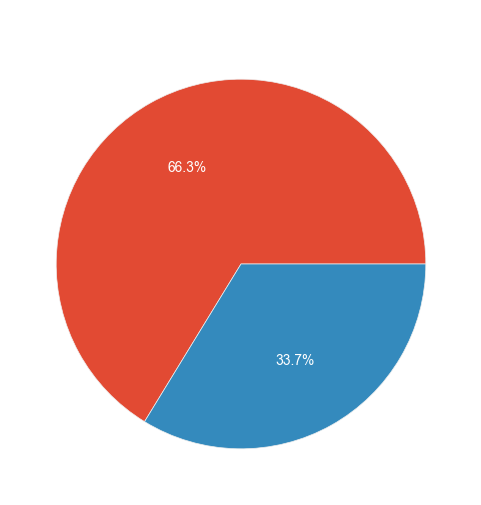

In [14]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.show()

## Fund Performance Correlation Matrix

This heatmap shows the correlation between key mutual fund performance metrics.

### Insight
Highly correlated metrics indicate similar performance behavior among mutual funds.

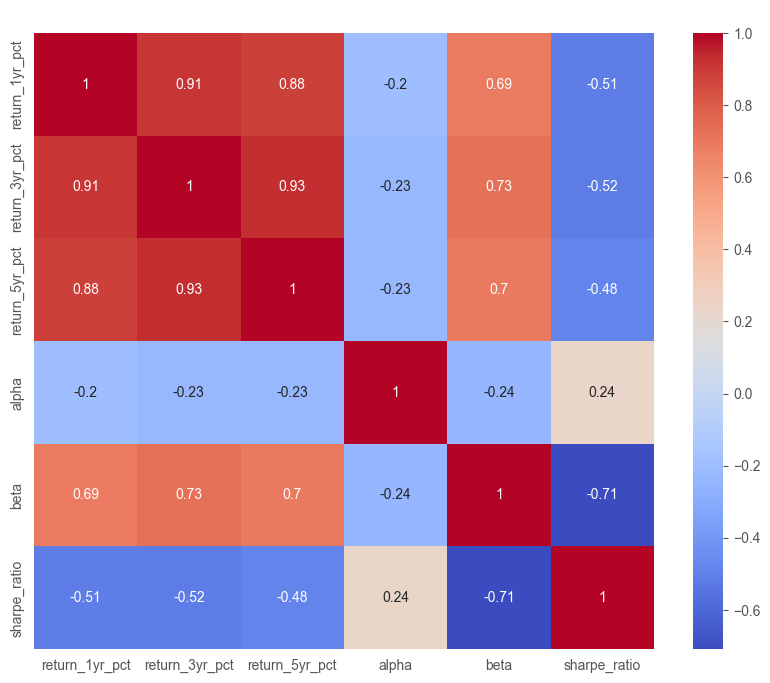

In [15]:
corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio"
]

corr_matrix = performance_data[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Performance Correlation Matrix")

plt.show()

## Expense Ratio Distribution

This histogram shows the spread of expense ratios across mutual fund schemes.

### Insight
Most funds cluster within a narrow expense ratio range, indicating competitive pricing among fund houses.

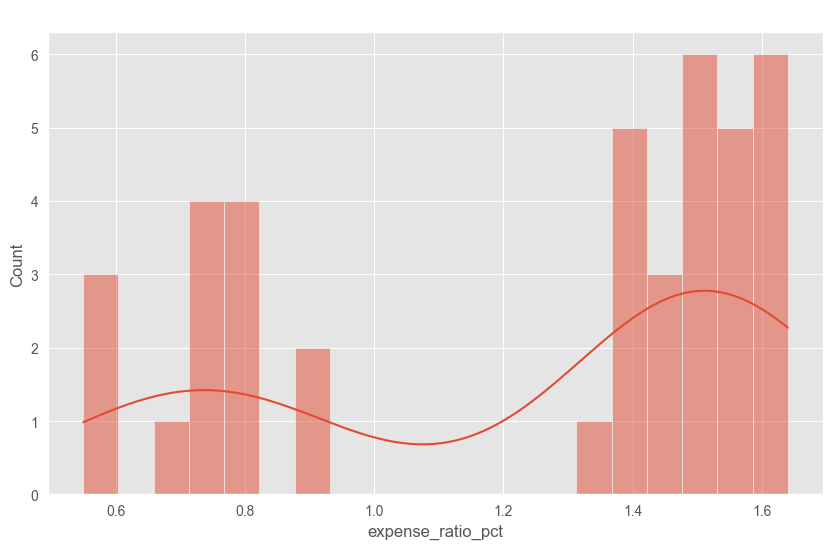

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance_data["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

## Top 10 Funds by AUM

This chart ranks the largest mutual funds by Assets Under Management.

### Insight
A small number of schemes account for a large share of industry assets.

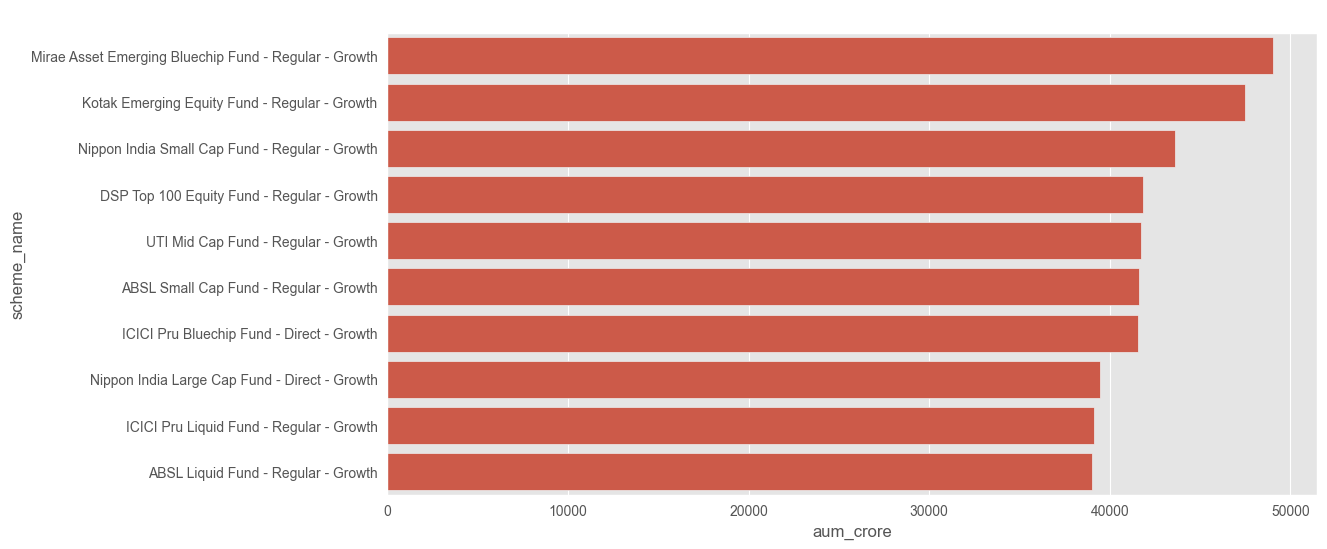

In [17]:
top_funds = (
    performance_data
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.show()

## Risk Grade Distribution

This chart shows the distribution of mutual fund schemes across different risk grades.

### Insight
Most schemes are concentrated in a few risk categories, indicating the overall risk profile of the mutual fund industry. Investors can use risk grades to align investments with their risk tolerance and financial goals.

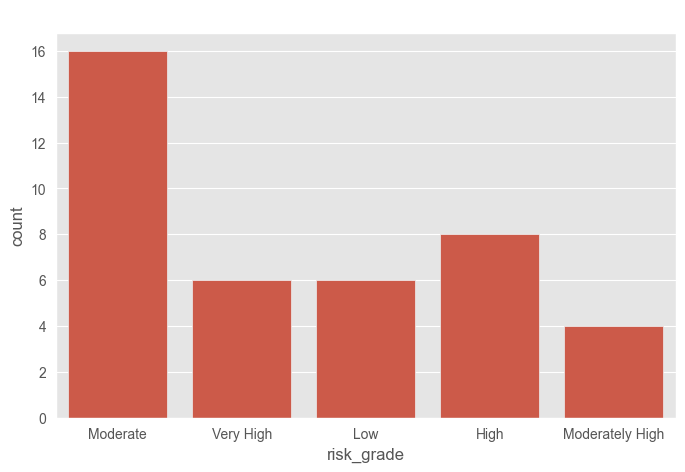

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance_data,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.show()

## Fund Category Distribution

This chart presents the number of mutual fund schemes across different categories such as Equity and Debt.

### Insight
The distribution highlights the dominance of specific fund categories and provides an overview of product availability in the mutual fund market. Equity funds typically represent a significant portion of available schemes due to higher investor demand.

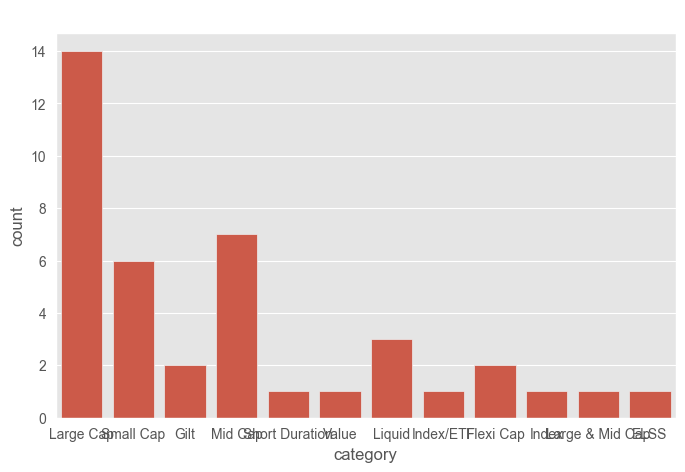

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance_data,
    x="category"
)

plt.title("Fund Category Distribution")

plt.show()

# Key EDA Findings

### Finding 1
NAV values across schemes generally show long-term upward growth trends from 2022–2026.

### Finding 2
Temporary corrections are visible during market downturn periods while overall growth remains positive.

### Finding 3
Assets Under Management (AUM) increased steadily across major fund houses.

### Finding 4
SIP inflows demonstrate consistent growth, indicating increasing retail investor participation.

### Finding 5
Category inflows vary significantly across fund categories, reflecting changing investor preferences.

### Finding 6
Investor participation is concentrated within a few age groups.

### Finding 7
A limited number of states contribute a significant share of total SIP investments.

### Finding 8
Mutual fund folio counts increased steadily, indicating growing market penetration.

### Finding 9
Fund performance metrics show meaningful correlations across return and risk measures.

### Finding 10
Most schemes are concentrated within a limited number of risk grades and fund categories.

# Conclusion

The exploratory analysis highlights strong growth in mutual fund adoption across India. Rising SIP inflows, increasing folio counts, and expanding AUM indicate growing investor participation. Performance, risk, demographic, and geographic analyses provide useful insights into investor behavior and fund characteristics. Overall, the mutual fund industry demonstrates sustained growth and diversification during the analysis period.